In [1]:
import os
import sys

sys.path.append('/data25/wuqin/projects/pytorch-grad-cam')
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['CUDA_VISIBLE_DEVICES'] = '5'
os.environ['HOME'] = '/data25/wuqin'
os.environ['CUDA_HOME'] = '/usr/local/cuda-11.8'

In [2]:
config_file = 'groundingdino/config/GroundingDINO_SwinB_cfg.py'
checkpoint_path = 'groundingdino_swinb_cogcoor.pth'

In [3]:
from demo.inference_on_a_image import load_image, load_model
model = load_model(config_file, checkpoint_path)

/data25/wuqin/miniforge3/envs/g_dino/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data25/wuqin/miniforge3/envs/g_dino/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/data25/wuqin/miniforge3/envs/g_dino/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


/data25/wuqin/projects/GroundingDINO/demo/inference_on_a_image.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_checkpoint_path, map_locati

_IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])


In [4]:
import torch
import torch.nn as nn
from typing import Optional
from groundingdino.util.utils import get_phrases_from_posmap

class GroundingDINO_CAM(nn.Module):
    """
    将 demo/inference_on_a_image.py 中的 get_grounding_output 封装为模块：
    - 在 forward 之前调用 set_prompt(caption, box_threshold, text_threshold)
    - forward(image: Tensor) 仅接收图像张量
    - 返回满足 logit > text_threshold 的所有 logit 的和（仅在 box 维度经 box_threshold 过滤后统计）
    """
    def __init__(self, model: nn.Module, cpu_only: bool = False, with_logits: bool = True) -> None:
        super().__init__()
        self.model = model
        self.caption: Optional[str] = None
        self.box_threshold: Optional[float] = None
        self.text_threshold: Optional[float] = None
        self.cpu_only = cpu_only
        self.with_logits = with_logits
        self.pred_boxes = self.pred_phrases = None

    def set_prompt(self, caption: str, box_threshold: float=0.3, text_threshold: float=0.25) -> None:
        caption = caption.lower().strip()
        if not caption.endswith("."):
            caption += "."
        self.caption = caption
        self.box_threshold = float(box_threshold)
        self.text_threshold = float(text_threshold)

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        """
        返回一个与模型参数可微分的标量，以便 Grad-CAM 进行反传：
        - 避免 no_grad 与布尔索引造成的图断裂
        - 用软阈值/ ReLU 近似原先的硬筛选
        """
        assert self.caption is not None, "请先调用 set_prompt(caption, box_threshold, text_threshold)"
        assert self.box_threshold is not None and self.text_threshold is not None, "阈值未设置"

        device = "cuda" if (not self.cpu_only and torch.cuda.is_available()) else "cpu"
        model = self.model.to(device)
        image = image.to(device)

        outputs = model(image, captions=[self.caption])
        # 保持在同一 device 上，避免提前 .cpu() 破坏图或导致跨设备反传
        logits = outputs["pred_logits"].sigmoid()[0]  # (nq, 256)
        boxes = outputs["pred_boxes"][0]

        # 1) 对 query 维度使用“软选择”权重，近似 keep = max(logit) > box_threshold
        q_scores = logits.max(dim=1).values  # (nq,)
        w_q = torch.relu(q_scores - self.box_threshold)  # (nq,)

        # 2) 对 token 维度使用 ReLU( logit - text_threshold )，近似 logit > text_threshold 的求和
        pos_logits = torch.relu(logits - self.text_threshold)  # (nq, 256)
        per_query = pos_logits.sum(dim=1)  # (nq,)

        # 3) 按 query 权重聚合成标量 loss（供 Grad-CAM 反传）
        loss = (w_q * per_query).sum()  # 标量

        # 仅用于可视化缓存（不影响梯度），这里可以做硬筛选并移到 CPU
        with torch.no_grad():
            keep = q_scores > self.box_threshold
            logits_kept = logits[keep]
            boxes_kept = boxes[keep]
            tokenlizer = model.tokenizer
            tokenized = tokenlizer(self.caption)
            pred_phrases = []
            for logit, box in zip(logits_kept, boxes_kept):
                pred_phrase = get_phrases_from_posmap(logit > self.text_threshold, tokenized, tokenlizer)
                if self.with_logits:
                    pred_phrases.append(pred_phrase + f"({str(logit.max().item())[:4]})")
                else:
                    pred_phrases.append(pred_phrase)
            self.pred_boxes = boxes_kept.detach().cpu()
            self.pred_phrases = pred_phrases

        # 维持与原先调用契合的 [1, 1] 形状
        return loss[None][None]

gdino_cam = GroundingDINO_CAM(model, cpu_only=False)


In [7]:
image_path = '/data25/wuqin/projects/pytorch-grad-cam/testset/test2.jpg'
text_prompt = 'green plant'
image_pil, image = load_image(image_path)
print(image_pil.size)
print(image.shape)
gdino_cam.set_prompt(caption=text_prompt, box_threshold=0.3, text_threshold=0.25)

(4096, 3072)
torch.Size([3, 800, 1066])


CAM形状: (800, 1066)


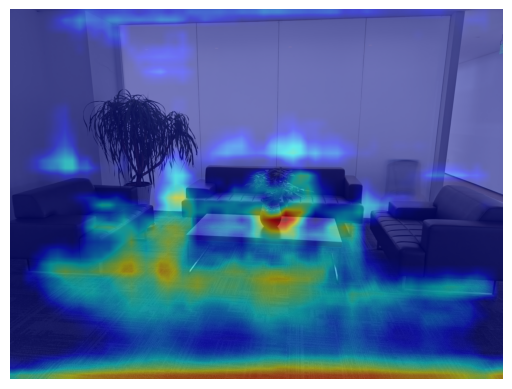

In [ ]:
# 创建GradCAM
from pytorch_grad_cam import GradCAM

# 针对骨干最后一层的归一化层作为 target layer
target_layers = [gdino_cam.model.backbone[0].layers[-1].blocks[-1].norm2]
cam = GradCAM(gdino_cam, target_layers, reshape_transform=lambda x: x.view(1, 25, 34, 1024).permute(0, 3, 1, 2))
try:
    input_tensor = image[None].clone()  # Grad-CAM 需要对参数反传，不必对输入开梯度
    grayscale_cam = cam(input_tensor)[0, :, :]
    print(f"CAM形状: {grayscale_cam.shape}")
except Exception as e:
    raise e
finally:
    for h in cam.activations_and_grads.handles:
        h.remove()

from pytorch_grad_cam.utils.image import show_cam_on_image
img = ((image-image.min()) / (image.max() - image.min())).permute(1, 2, 0).numpy()
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
import matplotlib.pyplot as plt
plt.imshow(cam_image)
plt.axis('off')
plt.show()

In [17]:
preds = torch.rand(8, 10).cuda()
label = [0, 0,0,0,0,1,2,3]
torch.nn.functional.cross_entropy(preds, torch.tensor(label).cuda())

tensor(2.3731, device='cuda:0')

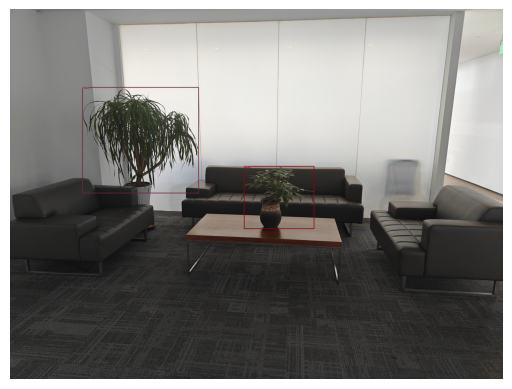

In [ ]:
from demo.inference_on_a_image import plot_boxes_to_image
import matplotlib.pyplot as plt
# visualize pred
size = image_pil.size
pred_dict = {
    "boxes": gdino_cam.pred_boxes,
    "size": [size[1], size[0]],  # H,W
    "labels": gdino_cam.pred_phrases,
}
# import ipdb; ipdb.set_trace()
image_with_box = plot_boxes_to_image(image_pil, pred_dict)[0]
plt.imshow(image_with_box)
plt.axis('off')
plt.show()